<style>
    .input_area, .output_area, pre, code {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>

In [104]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

import sqlite3 as db

import importlib
import sys

if 'trainTestSplit' in sys.modules:
    del sys.modules['trainTestSplit'] #remove cached version of trainTestSplit if it exists

sys.path.append("../src")
from trainTestSplit import get_reg_splits, modified_reg_splits, gam_splits

import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 
from pygam import LinearGAM, s

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, PredictionErrorDisplay
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE

Load the dataset

In [105]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_df = pd.read_sql_query("SELECT * FROM master", conn)

conn.close()

print(f"Data loaded successfully. Master dataset shape:, {master_df.shape[0]} records, {master_df.shape[1]} features.")
display(master_df.head())


Data loaded successfully. Master dataset shape:, 458 records, 23 features.


,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,race_white,race_hispanic,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,0.571876,-0.392703,-0.618768,1.897747,0.242736,-0.292939,0.376054,0.278606,0,0.581649
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,1.265442,-0.812366,-0.224057,-0.070897,9.043236,10.992720,9.194680,0.284134,0,3.480599
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,1.606091,-1.007781,-0.260578,-1.391047,-0.560484,-0.551553,-0.673864,0.151362,0,-0.618596
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-1.197404,-0.254952,-0.697429,-0.009136,-0.578973,-0.546764,-0.750563,0.313884,1,-0.264850
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,-1.057031,-0.429544,-0.791542,-0.541828,-0.078758,0.062656,-0.143792,0.633077,1,1.814352


Train/Test Split

In [106]:
X_train, X_test, y_train, y_test = get_reg_splits(master_df)
print(f"Training set: {X_train.shape[0]} records, {X_train.shape[1]} features.")
print(f"Testing set: {X_test.shape[0]} records, {X_test.shape[1]} features.")

print("\n====Training set features:====\n")
for col in X_train.columns:
    print(f"{col}: {X_train[col].dtype}")

Training set: 343 records, 17 features.
Testing set: 115 records, 17 features.

====Training set features:====

household_income: float64
home_ownership: float64
rental_houses: float64
food_nutrition: float64
employment: float64
housing_age: float64
code_violations: float64
foreclosures: float64
new_constructions: float64
age_of_residents: float64
race_black: float64
race_hispanic: float64
race_asian: float64
race_other: float64
transit_proximity: float64
grocery_proximity: float64
crime_total: float64


Features with high VIF and Multicollinearity were already identified and handled during the data prep/EDA process. These features were dropped when setting up the multiple linear regression UDF for train test split. To expedite the feature selection, a Recursive Feature Elimination (RFE) will be ran to find the best combination of features based on Adjusted R². This is because RFE is best suited for a Multiple Linear Regression as it considers features that are individually weak, but collectively strong predictors... or individually strong but redundant with others.

In [107]:
lr = LinearRegression()

for k in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=lr, n_features_to_select=k)
    rfe.fit(X_train, y_train)

    X_selected = rfe.transform(X_train)

    r2_scores = cross_val_score(lr, X_selected, y_train, cv=8, scoring="r2")
    mean_r2 = r2_scores.mean()
    n, p = X_train.shape[0], k
    adj_r2 = 1 - (1 - mean_r2) * (n - 1) / (n - p - 1)
    
    selected = X_train.columns[rfe.support_].tolist()
    print(f"\nk={k}: Adj R²={adj_r2:.4f}")
    print(f"  Features: {selected}")


k=1: Adj R²=0.5919
  Features: ['home_ownership']

k=2: Adj R²=0.6911
  Features: ['household_income', 'home_ownership']

k=3: Adj R²=0.7085
  Features: ['household_income', 'home_ownership', 'food_nutrition']

k=4: Adj R²=0.7122
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents']

k=5: Adj R²=0.7137
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'race_asian']

k=6: Adj R²=0.7125
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian']

k=7: Adj R²=0.7095
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian', 'crime_total']

k=8: Adj R²=0.7070
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian', 'grocery_proximity', 'crime_total']

k=9: Adj R²=0.7061
  Features: ['household_income', 'home_ownership', 'fo

`race_asian` was selected by RFE multiple times. However, there's no theoretical justification for why it should be included. Also, given the sensitive nature of this project, I'm going to try to exclude it and run the RFE analysis again.

In [108]:
# Remove race_asian from X_train temporarily
X_train = X_train.drop(columns=["race_asian"])

lr = LinearRegression()
results = []

for k in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=lr, n_features_to_select=k)
    rfe.fit(X_train, y_train)
    X_selected = rfe.transform(X_train)
    r2_scores = cross_val_score(lr, X_selected, y_train, cv=5, scoring="r2")
    mean_r2 = r2_scores.mean()
    n, p = X_train.shape[0], k
    adj_r2 = 1 - (1 - mean_r2) * (n - 1) / (n - p - 1)
    selected = X_train.columns[rfe.support_].tolist()
    print(f"k={k}: Adj R²={adj_r2:.4f} | Features: {selected}")

k=1: Adj R²=0.5981 | Features: ['home_ownership']
k=2: Adj R²=0.6989 | Features: ['household_income', 'home_ownership']
k=3: Adj R²=0.7143 | Features: ['household_income', 'home_ownership', 'food_nutrition']
k=4: Adj R²=0.7194 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents']
k=5: Adj R²=0.7185 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'grocery_proximity']
k=6: Adj R²=0.7182 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'transit_proximity', 'grocery_proximity']
k=7: Adj R²=0.7187 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'transit_proximity', 'grocery_proximity']
k=8: Adj R²=0.7160 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_black', 'transit_proximity', 'grocery_proximity']
k=9: Adj R²=0.7160 | Features: ['household_income

After removing `race_asian`, the possible features associated with the highest Adj R² are more plausible explanations for `housing_cost_burden`.   
Adj R² also starts to decrease once more than four features are added. K-fold 5 includes:    
- `household_income` is an obvious direct measure of being able to afford housing.  
- `home_ownership` gives us insight on the stability of the population in the neighborhood
- `food_nutrition` is a proxy variable for poverty as a high food nutrition services is usually associated with lower income which equals higher burden
- `age_of_residents` older residents tend to be long term home owners with lower mortgage rates. Less younger populations tend to be an indicator of a dwindling quality of life.

However, we believe that the features for k=7, while having a slightly lower score, can tell a richer story.
- `new_construction` could indicate gentrification. Especially given Charlotte's population growth over the decades.  
- `transit_proximity` access to public transportation can affect housing costs. Too close and you're paying a lot for convenience. Too far makes it difficult to get around, especially commuting to a job.
- `grocery_proximity` food access, can be a proxy for urban development and population density.
  
The difference in scores is negligible. We think the penalty in the score is worth it for the addtional insight. 
A new train/test split will be created with these features in mind.


New Train/Test Split

In [109]:
X_train, X_test, y_train, y_test = modified_reg_splits(master_df)

print(f"Modified Training set: {X_train.shape[0]} records, {X_train.shape[1]} features.")
print(f"Modified Testing set: {X_test.shape[0]} records, {X_test.shape[1]} features.")
print("\n====Modified Training set features:====\n")

for col in X_train.columns:
    print(f"{col}: {X_train[col].dtype}")

Modified Training set: 343 records, 7 features.
Modified Testing set: 115 records, 7 features.

====Modified Training set features:====

household_income: float64
home_ownership: float64
food_nutrition: float64
new_constructions: float64
age_of_residents: float64
transit_proximity: float64
grocery_proximity: float64


Model Fit

In [110]:
#OLS Regression with statsmodels

# Add constant
X2_train = sm.add_constant(X_train)

# Fit model
ols_model = sm.OLS(y_train, X2_train).fit()

# Predict
X2_test = sm.add_constant(X_test)
y_pred = ols_model.predict(X2_test)

# Summary
print(ols_model.summary())


                             OLS Regression Results                            
Dep. Variable:     housing_cost_burden   R-squared:                       0.736
Model:                             OLS   Adj. R-squared:                  0.730
Method:                  Least Squares   F-statistic:                     133.1
Date:                 Thu, 30 Apr 2026   Prob (F-statistic):           8.88e-93
Time:                         17:19:14   Log-Likelihood:                 357.12
No. Observations:                  343   AIC:                            -698.2
Df Residuals:                      335   BIC:                            -667.5
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2766

Two features are not statistically significant: `transit_proximity` and `grocery_proximity`. Their p-values are well above a significance level of 0.05. So we fail to reject the null hypothesis that their coefficients = 0. We thought they might add more insight to our narrative, but the data doesn't really back them up and just add noise. We'll have to drop them.  

Also, we have a really high kurtosis and a heavy right skew. 

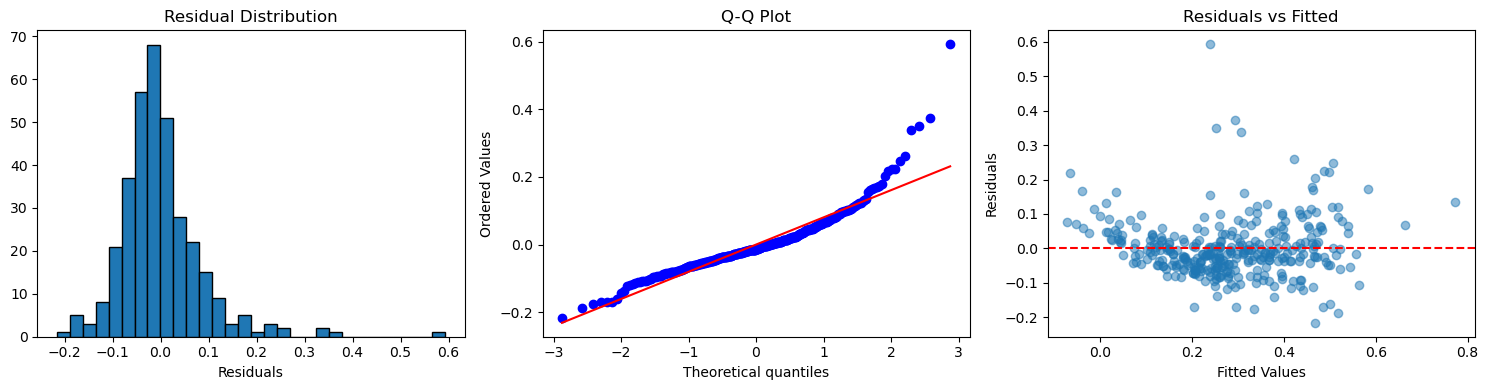


Outliers (|residual| > 3 std): 5
439    0.260985
229    0.373902
198    0.338172
222    0.592733
37     0.349762
dtype: float64


In [111]:
# Get residuals
residuals = ols_model.resid

# Plot residual distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(residuals, bins=30, edgecolor="black")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residuals")

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

# Residuals vs fitted
axes[2].scatter(ols_model.fittedvalues, residuals, alpha=0.5)
axes[2].axhline(y=0, color="red", linestyle="--")
axes[2].set_title("Residuals vs Fitted")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

# Identify extreme outliers
outlier_threshold = 3 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]
print(f"\nOutliers (|residual| > 3 std): {len(outliers)}")
print(outliers)

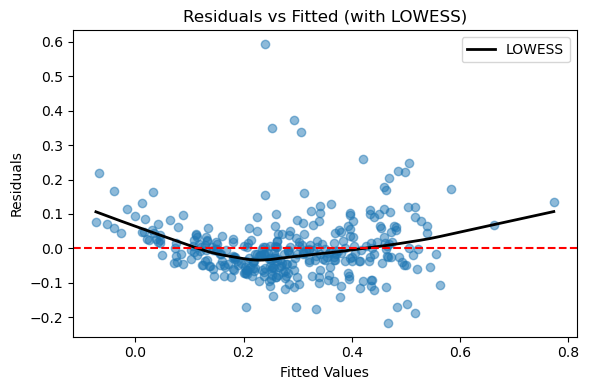

In [112]:
# Add LOWESS curve to Residuals vs Fitted plot
lowess = sm.nonparametric.lowess(residuals, ols_model.fittedvalues, frac=0.5)

plt.figure(figsize=(6, 4))
plt.scatter(ols_model.fittedvalues, residuals, alpha=0.5)
plt.plot(lowess[:, 0], lowess[:, 1], color="black", lw=2, label="LOWESS")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals vs Fitted (with LOWESS)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.legend()
plt.tight_layout()
plt.show()

Upper Right tail of the Q-Q Plot shows the upper right tail shooting far above the reference line. The Residual vs Fitted plot not only fans out due to heteroscedasticity, but the LOWESS shows a shallow u-shape as well. This means OLS overpredicted at low and high fitted values and under predicted mid-range. This confirms we have some non-linearity going on. We also identified 5 extreme outliers.

In [113]:
outlier_idx = outliers.index

# Look up in master_df using original features
print(master_df.loc[outlier_idx, ["NPA", "household_income", "home_ownership", 
                                   "food_nutrition", "age_of_residents", 
                                   "housing_cost_burden"]])

     NPA  household_income  home_ownership  food_nutrition  age_of_residents  \
439  456         -0.347555       -0.768726       -1.056336          4.840199   
229  234         -0.907992        0.573681        0.772220         -0.862104   
198  202         -1.048112        0.252138        0.591117         -1.242258   
222  227         -0.630557        0.789230        0.141280          0.047549   
37    39         -0.303283        0.550903        0.281489          0.169741   

     housing_cost_burden  
439             0.682209  
229             0.667916  
198             0.643629  
222             0.832372  
37              0.602305  


In [114]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_df = pd.read_sql_query("SELECT * FROM qol WHERE NPA IN (456, 234, 202, 227, 39)", conn)

conn.close()

print(f"Data loaded successfully. Master dataset shape:, {master_df.shape[0]} records, {master_df.shape[1]} features.")
display(master_df)

Data loaded successfully. Master dataset shape:, 5 records, 25 features.


,NPA,household_income,home_ownership,home_sales_price,rental_cost,rental_houses,food_nutrition,health_insurance,employment,housing_age,...,race_black,race_white,race_hispanic,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,crime_property,crime_violent
0,39,75321.0,72.875817,1772045.0,1229.0,284.0,0.241,0.0,94.391843,32.0,...,44.61,20.51,25.27,4.62,5.00,44.0,398.5,143.0,25.0,5.0
1,202,41875.0,64.612326,897500.0,1219.0,136.0,0.294,0.0,77.462888,43.0,...,27.95,12.41,47.10,9.93,2.62,706.0,272.0,290.0,27.0,9.0
2,227,60625.0,79.467681,1801065.0,1760.0,275.0,0.217,0.0,97.676420,28.0,...,48.13,22.72,21.58,2.32,5.25,380.0,398.5,362.0,17.0,7.0
3,234,48167.0,73.505853,1205319.0,1020.0,354.0,0.325,0.0,95.633999,32.0,...,27.70,22.08,41.48,4.60,4.14,2046.0,398.5,362.0,318.0,38.0
4,456,73333.0,36.376404,506412.0,3011.0,36.0,0.012,0.0,97.313433,31.0,...,2.71,88.70,3.99,1.89,2.71,325.0,325.0,293.0,0.0,0.0


These 5 neighborhoods have extremely high housing cost burden (ranging from 60% - 83% of household income) and a below average household income. They drive housing cost burden in a way the available features cannot capture, since price variables were excluded to prevent target leakage. ***Further research into these neighborhoods is required*** We'll be sure to include them in our post analysis for HOLC grading.

Next Step:  
Linear regression assumes that each feature has a fixed, linear relationship with the target. This is obviously not the case here. A Generalized Additive Model (GAM) will give us some leeway with this assumption by replacing each linear term in the model with a smooth, flexible function that's learned from the data. The function is a spline that bends and flattens when needed (much like when you reel in a big fish with a flexible fishing rod). Each feature contributes independently and preserves interpretability, visualized through partial dependence plots. 

In [115]:
# Fit the GAM
# s(i) = spline term for column i (0-indexed)
# 0: household_income  1: home_ownership    2: food_nutrition
# 3: new_constructions 4: age_of_residents  5: transit_proximity
# 6: grocery_proximity

gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6))
gam.gridsearch(X_train.values, y_train.values)  # auto-tunes lambda (smoothing penalty)

# Evaluate on test set
y_pred_gam = gam.predict(X_test.values)

r2_gam  = r2_score(y_test, y_pred_gam)
rmse_gam = root_mean_squared_error(y_test, y_pred_gam)

print("=" * 40)
print("GAM vs OLS Performance on Test Set:")
print(f"GAM   — R²: {r2_gam:.4f} | RMSE: {rmse_gam:.4f}")
print(f"OLS   — R²: {r2_score(y_test, y_pred):.4f} | RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print("=" * 40)
print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:01 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:01 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02


GAM vs OLS Performance on Test Set:
GAM   — R²: 0.8273 | RMSE: 0.0668
OLS   — R²: 0.6920 | RMSE: 0.0892
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     21.4994
Link Function:                     IdentityLink Log Likelihood:                                   434.2459
Number of Samples:                          343 AIC:                                             -823.4929
                                                AICc:                                            -820.1833
                                                GCV:                                                0.0056
                                                Scale:                                              0.0704
                                        

C:\Users\ejtes\AppData\Local\Temp\ipykernel_32616\1008128410.py:21: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


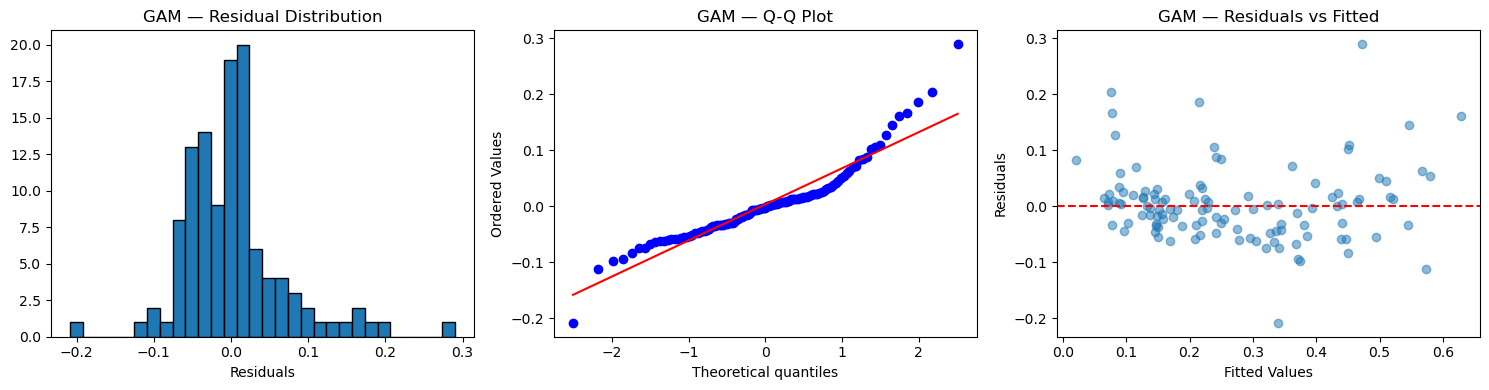

In [116]:
# examine residuals for GAM
gam_residuals = y_test.values - y_pred_gam

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gam_residuals, bins=30, edgecolor="black")
axes[0].set_title("GAM — Residual Distribution")
axes[0].set_xlabel("Residuals")

stats.probplot(gam_residuals, dist="norm", plot=axes[1])
axes[1].set_title("GAM — Q-Q Plot")

axes[2].scatter(y_pred_gam, gam_residuals, alpha=0.5)
axes[2].axhline(y=0, color="red", linestyle="--")
axes[2].set_title("GAM — Residuals vs Fitted")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Looking across all three diagnostics, the GAM shows improvement over OLS.  
The residual distribution shifted from a right-skewed histogram to a near-symmetric distribution centered tightly around zero.  
 The Q-Q plot from OLS showed severe right skew with the upper tail, while the GAM's deviations are a bit more modest and symmetric. The tail deviations are due to the five high-burden outlier neighborhoods.   
 The residuals vs. fitted plot shows significant improvement. OLS had a U-shaped trend (confirmed by LOWESS) and a fan pattern, which hinted at non-linearity and heteroscedasticity. The GAM residuals are scattered much more evenly around zero with no visible trend.  
 Overall we believe the GAM diagnostics indicate a substantially better-specified model for this data.

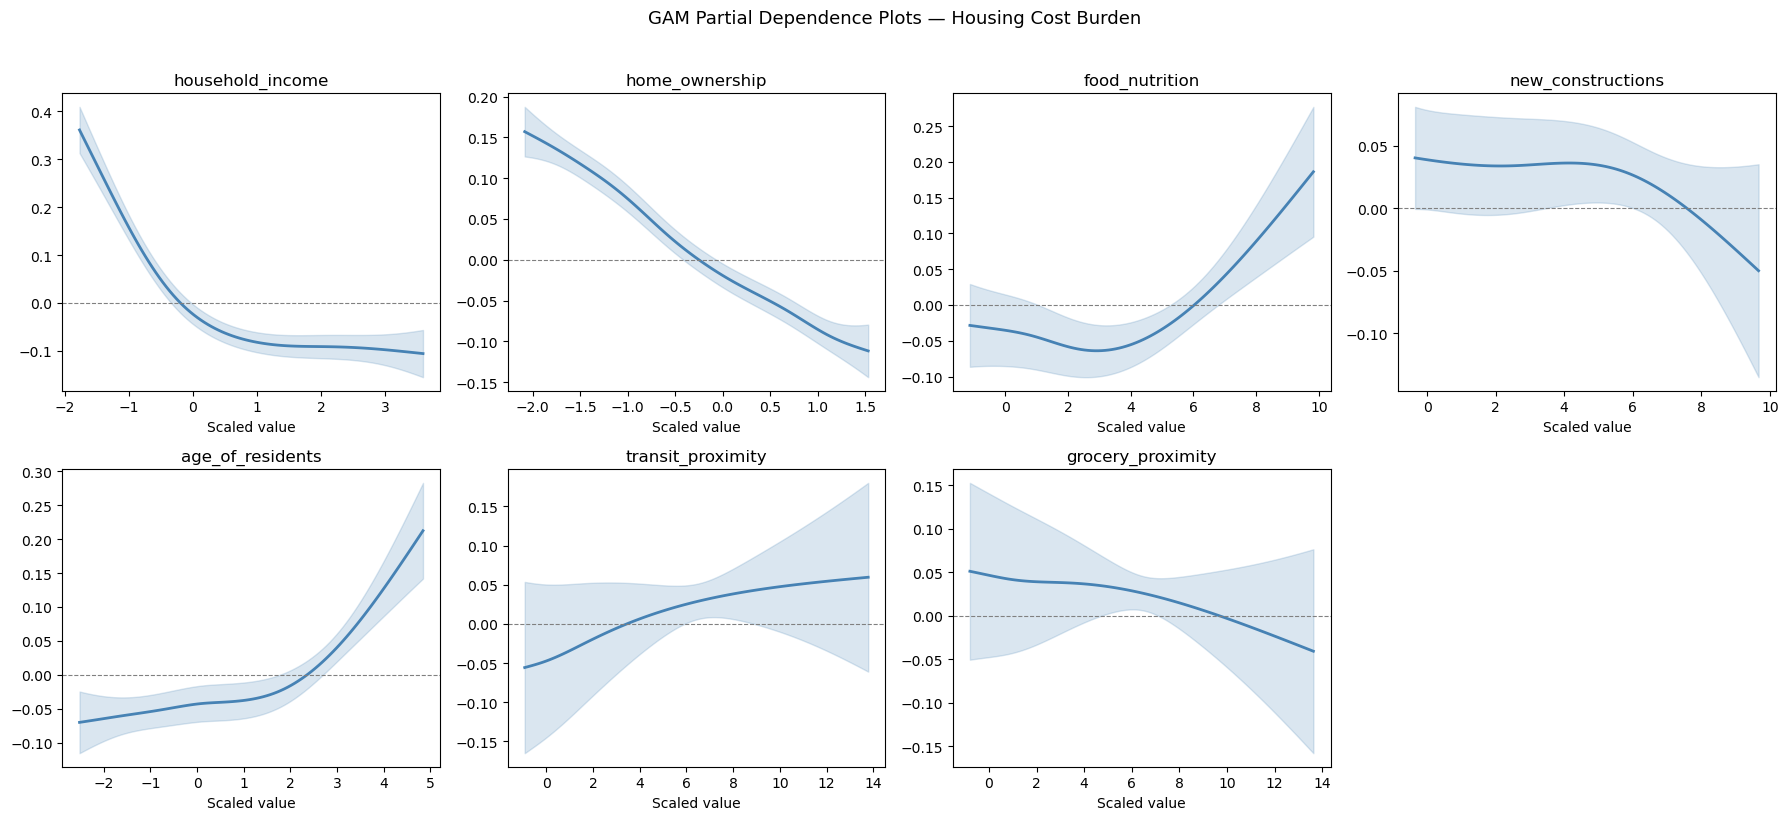

In [117]:
# partial dependence plots for each feature
feature_names = ["household_income", "home_ownership", "food_nutrition",
                 "new_constructions", "age_of_residents",
                 "transit_proximity", "grocery_proximity"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, feature_names)):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX), color="steelblue", lw=2)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1],
            color="steelblue", alpha=0.2, lw=0)
    ax.fill_between(XX[:, i],
                    *gam.partial_dependence(term=i, X=XX, width=0.95)[1].T,
                    alpha=0.2, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Scaled value")
    ax.axhline(y=0, color="gray", linestyle="--", lw=0.8)

axes[-1].set_visible(False)  # hide the empty 8th subplot
plt.suptitle("GAM Partial Dependence Plots — Housing Cost Burden", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

`household_income`, `home_ownership`, `food nutrition`, and `age_of_residents` all show non-linear curves, which explains why OLS was not a good fit.  

- `household_income` : steep decline, then flattens near the mean. When household income falls below average, housing cost burden is significantly increased.
- `home_ownership` : Higher ownership rates leads to less burden, which means renters are more cost-burdened.
- `food_nutrition` : housing cost burden starts to spike in neighborhoods where reliance on food and nutrition services reach a scaled value of about 4.
- `new_construction`, `transit_proximity` , and `grocery_proximity` : large confidence intervals and doesn't contribute any useful information. Will drop.
- `age_of_residents` : younger neighborhoods have a lower burden while older residents face more burden. Likely because long-term residents on a fixed income are less able to absorb the rising housing costs.

We are back to using the original 4 features recommended by RFE. So much for trying to expedite feature selection. Will re-train/re-test with new features and run a final model using GAM.

Train/Test Split #3

In [118]:
X_train, X_test, y_train, y_test = gam_splits(master_df)

print(f"Modified Training set: {X_train.shape[0]} records, {X_train.shape[1]} features.")
print(f"Modified Testing set: {X_test.shape[0]} records, {X_test.shape[1]} features.")
print("\n====Modified Training set features:====\n")

for col in X_train.columns:
    print(f"{col}: {X_train[col].dtype}")

KeyError: 'housing_cost_burden'